# Improving Neural Networks Performance
1. Vanishing/Exploding Gradients
    - Activation Functions: Use ReLU or its variants instead of sigmoid/tanh.
    - Weight Initialization: Use techniques like He or Xavier initialization.
2. Overfitting
    - Reduce Model Complexity: Use fewer layers or neurons.
    - Increase Training Data: Use data augmentation or gather more data.
    - Dropout Layers: Randomly drop neurons during training to prevent co-adaptation.
    - Regularization: Apply L1 or L2 regularization to penalize large weights.
    - Early Stopping: Stop training when validation performance starts to degrade.
3. Normalization
    - Normalizaion Inputs: Scale input features to a standard range (e.g., 0-1 or mean=0, std=1).
    - Batch Normalization: Normalize activations in each layer to improve training speed and stability.
    - Normalization Activations: Use techniques like Layer Normalization or Instance Normalization for better performance.
4. Gradient Checking and Clipping
    - Gradient Checking: Verify the correctness of backpropagation implementation.
    - Gradient Clipping: Limit the magnitude of gradients to prevent exploding gradients.
5. Optimizers
    - Momentum: Accelerate gradient descent by adding a fraction of the previous update to the current update.
    - AudaGrad: Adapt learning rates based on the frequency of parameter updates.
    - RMSProp: Adapt learning rates based on a moving average of squared gradients.
    - Adam: Combine momentum and RMSProp for efficient optimization.
6. Learning Rate Scheduling
    - Step Decay: Reduce learning rate by a factor at specific intervals.
    - Exponential Decay: Reduce learning rate exponentially over time.
    - Cyclical Learning Rates: Vary learning rate cyclically between a lower and upper bound.
7. Hyperparameter Tuning
    - Grid Search: Systematically explore combinations of hyperparameters.
    - Random Search: Randomly sample hyperparameter combinations for evaluation.
    - Bayesian Optimization: Use probabilistic models to find optimal hyperparameters efficiently.

### Standard Scaling
Standard scaling, also known as Z-score normalization, is a technique used to standardize the features of a dataset. It transforms the data to have a mean of zero and a standard deviation of one. This is achieved by subtracting the mean of each feature from the data points and then dividing by the standard deviation.
```math
X' = \frac{X - \mu}{\sigma}
```
Where:
- $X$ is the original feature value,
- $\mu$ is the mean of the feature,
- $\sigma$ is the standard deviation of the feature

In sklearn, use of `StandardScaler` is common for standard scaling.

### Normalization
Normalization, also known as Min-Max scaling, is a technique used to scale the features of a dataset to a specific range, typically [0, 1]. This is achieved by subtracting the minimum value of the feature from the data points and then dividing by the range (max - min).
```math
X' = \frac{X - X_{min}}{X_{max} - X_{min}}
```
Where:
- $X$ is the original feature value,
- $X_{min}$ is the minimum value of the feature,
- $X_{max}$ is the maximum value of the feature

In sklearn, use of `MinMaxScaler` is common for normalization.


#### Standardization vs Normalization
| Technique       | When to Use                         | Common Cases                      | Why Use It?                          |
|-----------------|-------------------------------------|-----------------------------------|---------------------------------------|
| Standardization | - Data is roughly Gaussian(normal like),<br> - Care about distance/gradients/optimization | - Neural Networks,<br> -Logistic Regression,<br> -Linear Regression,<br> -SVM,<br> -PCA | - Handles outliers better,<br> - Make gradients more stable,<br> - Often leads to faster convergence |
| Normalization   | - Data is not Gaussian,<br> - Values need to be in a specific range(0-1 or -1 to 1),<br> - No assumptions about distribution,<br> - Features have known bounds | - Image data(pixel values 0-255 to 0-1),<br> - KNN,<br> - K-Means,<br> - Distance-based models with bounded data | - Preserves shape but rescales extremes,<br> - Useful when scale must be controlled |

`Important Difference:` Standardization: Keeps Outliers -> Just Rescales Distribution, Normalization: Rescales to a Range -> Can Squash Outliers

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv('Social_Network_Ads.csv')
df = df.iloc[:, 2:]
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [8]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

scaler = StandardScaler()
X_train_scaled = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
X_test_scaled = torch.tensor(scaler.transform(X_test), dtype=torch.float32)

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x


model = Model()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
val_acc_list = []

for epoch in range(epochs):
    outputs = model(X_train_scaled)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        val_outputs = model(X_test_scaled)
        preds = (val_outputs > 0.5).float()
        acc = (preds == y_test).float().mean()
        val_acc_list.append(acc.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

Epoch 0, Loss: 0.8132, Val Acc: 0.4000
Epoch 10, Loss: 0.7089, Val Acc: 0.4000
Epoch 20, Loss: 0.6252, Val Acc: 0.7500
Epoch 30, Loss: 0.5603, Val Acc: 0.8125
Epoch 40, Loss: 0.5105, Val Acc: 0.8125
Epoch 50, Loss: 0.4717, Val Acc: 0.8250
Epoch 60, Loss: 0.4408, Val Acc: 0.8250
Epoch 70, Loss: 0.4154, Val Acc: 0.8250
Epoch 80, Loss: 0.3941, Val Acc: 0.8250
Epoch 90, Loss: 0.3758, Val Acc: 0.8375


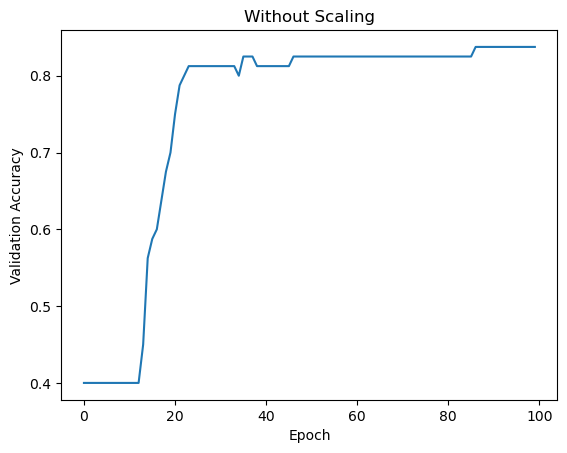

In [9]:
plt.plot(val_acc_list)
plt.title("Without Scaling")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.show()